# Trump Truth Social Data: Load, Deduplicate & Explore

**Data source:** Scraped via Truth Social web scraper, stored as JSON files  
**Files:**
- `realDonaldTrump_truths.json` — most recent batch  
- `realDonaldTrump_truths_2.json` — second batch  
- `realDonaldTrump_truths_3.json` — third batch (overlaps exist)  

**Step 1 goals:**
1. Load all three files and concatenate  
2. Explore the raw data before touching it  
3. Deduplicate on post `id`  
4. Audit every column — types, nulls, nested structure, keep-vs-drop

In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from bs4 import BeautifulSoup

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## 1.1 — Load all three files

In [4]:
DATA_DIR = Path('.')  # notebook lives inside TrumpData/

files = [
    DATA_DIR / 'realDonaldTrump_truths.json',
    DATA_DIR / 'realDonaldTrump_truths_2.json',
    DATA_DIR / 'realDonaldTrump_truths_3.json',
]

frames = []
for f in files:
    chunk = pd.read_json(f, lines=True)
    chunk['_source_file'] = f.name
    frames.append(chunk)
    print(f'{f.name}: {len(chunk):,} rows')

raw = pd.concat(frames, ignore_index=True)
raw['created_at'] = pd.to_datetime(raw['created_at'], utc=True)
print(f'\nTotal before deduplicate: {len(raw):,} rows')

realDonaldTrump_truths.json: 2,280 rows
realDonaldTrump_truths_2.json: 2,640 rows
realDonaldTrump_truths_3.json: 2,200 rows

Total before deduplicate: 7,120 rows


## 1.2 — Initial exploration of raw data

Before anything else: what does one record actually look like? Flat fields first, then the nested ones separately so it stays readable.

In [8]:
NESTED = {'account', 'card', 'media_attachments', 'mentions', 'tags', 'quote', 'reblog', 'emojis'}

sample = raw.iloc[100].to_dict()

print('=== FLAT FIELDS ===')
print(json.dumps({k: v for k, v in sample.items() if k not in NESTED}, indent=2, default=str))

print('\n=== NESTED: account (key fields) ===')
acc = sample['account']
if isinstance(acc, dict):
    print(json.dumps({k: acc[k] for k in ['username', 'followers_count', 'following_count', 'statuses_count']}, indent=2))

print('\n=== NESTED: card ===')
card = sample.get('card')
if isinstance(card, dict):
    print(json.dumps({k: card.get(k) for k in ['url', 'title', 'description', 'provider_name', 'type']}, indent=2))
else:
    print('(no card on this post — pick a post with a link to see one)')

=== FLAT FIELDS ===
{
  "id": 116346686438015344,
  "created_at": "2026-04-04 13:32:26.478000+00:00",
  "in_reply_to_id": NaN,
  "quote_id": NaN,
  "in_reply_to_account_id": NaN,
  "sensitive": false,
  "spoiler_text": "",
  "visibility": "public",
  "language": "en",
  "uri": "https://truthsocial.com/@realDonaldTrump/116346686438015338",
  "url": "https://truthsocial.com/@realDonaldTrump/116346686438015338",
  "content": "<p>Not only were the jobs numbers GREAT yesterday, 178,000 new jobs, but the TRADE DEFICIT was down 55%, the biggest drop in history. THANK YOU MR. TARIFF! All of this and, simultaneously, getting rid of a Nuclear Iran. MAGA!!!</p>",
  "group": NaN,
  "in_reply_to": NaN,
  "sponsored": false,
  "replies_count": 3270,
  "reblogs_count": 10159,
  "favourites_count": 49325,
  "reaction": NaN,
  "upvotes_count": 49325,
  "downvotes_count": 0,
  "favourited": false,
  "reblogged": false,
  "muted": false,
  "pinned": false,
  "bookmarked": false,
  "poll": NaN,
  "votable

## 1.3 — Post types

Truth Social has three post types: original posts, ReTruths (reblogs of others), and quoted posts.  
ReTruths have no original text in `content` — we'll need to handle them separately in Step 2.

In [9]:
n_raw = len(raw)
n_reblogs  = raw['reblog'].notna().sum()
n_quotes   = raw['quote_id'].notna().sum()
n_original = n_raw - n_reblogs

breakdown = pd.DataFrame([
    {'type': 'Original truths',    'count': n_original, 'pct': n_original / n_raw * 100},
    {'type': 'ReTruths (reblogs)', 'count': n_reblogs,  'pct': n_reblogs  / n_raw * 100},
    {'type': 'Contains a quote',   'count': n_quotes,   'pct': n_quotes   / n_raw * 100},
])
breakdown['pct'] = breakdown['pct'].round(1).astype(str) + '%'
print(breakdown.to_string(index=False))

# Show who gets ReTruthed most
reblogs = raw[raw['reblog'].notna()]
if len(reblogs):
    retruthed_authors = reblogs['reblog'].apply(
        lambda x: x.get('account', {}).get('username') if isinstance(x, dict) else None
    )
    print('\nMost ReTruthed accounts:')
    print(retruthed_authors.value_counts().head(5).to_string())

              type  count   pct
   Original truths   6877 96.6%
ReTruths (reblogs)    243  3.4%
  Contains a quote   1135 15.9%

Most ReTruthed accounts:
reblog
realDonaldTrump      179
DanScavino             9
rapidresponse47        6
IStandWithTrump47      5
PressSec               5


## 1.4 — Posting activity over time

Daily posting volume across the full raw dataset. Spikes are often tied to breaking news or political events — exactly what we want to cross-reference with oil prices, inflation, and S&P data.

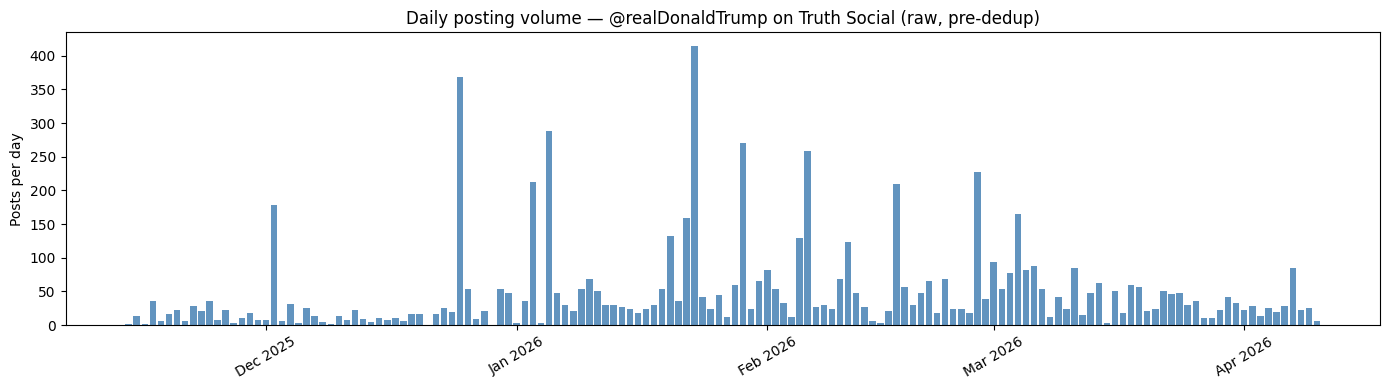

Top 5 most active days:
      date  posts
2026-01-23    414
2025-12-25    369
2026-01-05    288
2026-01-29    270
2026-02-06    258


In [10]:
daily = raw.set_index('created_at').resample('D').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily.index, daily.values, width=0.8, color='steelblue', alpha=0.85)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.set_title('Daily posting volume — @realDonaldTrump on Truth Social (raw, pre-dedup)')
ax.set_ylabel('Posts per day')
plt.tight_layout()
plt.show()

top_days = daily.nlargest(5).reset_index()
top_days.columns = ['date', 'posts']
top_days['date'] = top_days['date'].dt.date
print('Top 5 most active days:')
print(top_days.to_string(index=False))

## 1.5 — Content length distribution

How long are the posts? Measured as raw HTML character count (before stripping tags).  
Very short posts are usually image-only or ReTruths with no added text; very long ones tend to be policy rants.

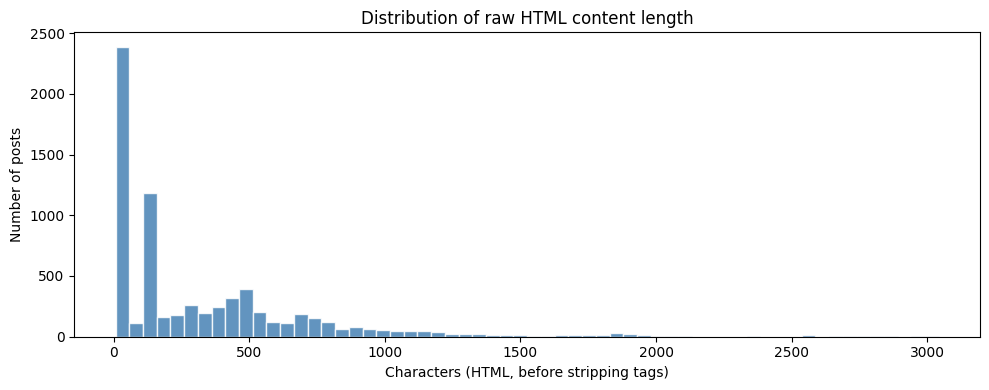

count    7120.0
mean      343.0
std       445.0
min         7.0
25%         7.0
50%       127.0
75%       498.0
max      3043.0
Name: _html_len, dtype: float64

Posts with empty content: 0


In [11]:
raw['_html_len'] = raw['content'].str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(raw['_html_len'].dropna(), bins=60, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_title('Distribution of raw HTML content length')
ax.set_xlabel('Characters (HTML, before stripping tags)')
ax.set_ylabel('Number of posts')
plt.tight_layout()
plt.show()

print(raw['_html_len'].describe().round(0))
print(f'\nPosts with empty content: {(raw["_html_len"] == 0).sum()}')

## 1.6 — Top 10 posts by engagement

What are the highest-engagement posts in the raw data? Gives a qualitative feel for the content that resonates, and a sanity-check that the counts look plausible.

In [12]:
def strip_html(html):
    if pd.isna(html) or html == '':
        return '(no text)'
    return BeautifulSoup(html, 'lxml').get_text(separator=' ').strip()

top10 = raw.nlargest(10, 'favourites_count').copy()
top10['text'] = top10['content'].apply(strip_html).str[:120]
top10['date'] = top10['created_at'].dt.date

top10[['date', 'favourites_count', 'reblogs_count', 'replies_count', 'text']]

,date,favourites_count,reblogs_count,replies_count,text
2677,2026-02-28,100458,26759,18148,"Khamenei, one of the most evil people in History, is dead. This is not only Justice for the peop..."
670,2026-02-28,100415,26722,18091,"Khamenei, one of the most evil people in History, is dead. This is not only Justice for the peop..."
5590,2026-02-28,100415,26722,18091,"Khamenei, one of the most evil people in History, is dead. This is not only Justice for the peop..."
4034,2026-01-03,97997,24651,16652,The United States of America has successfully carried out a large scale strike against Venezuela...
2027,2026-01-03,97957,24627,16611,The United States of America has successfully carried out a large scale strike against Venezuela...
6947,2026-01-03,97957,24627,16611,The United States of America has successfully carried out a large scale strike against Venezuela...
90,2026-04-05,88290,20433,23989,"Tuesday will be Power Plant Day, and Bridge Day, all wrapped up in one, in Iran. There will be n..."
5010,2026-04-05,88290,20433,23990,"Tuesday will be Power Plant Day, and Bridge Day, all wrapped up in one, in Iran. There will be n..."
92,2026-04-05,87735,20383,11094,"FROM PRESIDENT DONALD J. TRUMP WE GOT HIM! My fellow Americans, over the past several hours, the..."
5012,2026-04-05,87735,20383,11094,"FROM PRESIDENT DONALD J. TRUMP WE GOT HIM! My fellow Americans, over the past several hours, the..."


## 1.7 — Deduplicate on post `id`

The files have temporal overlap (file 3 contains the same April-10 posts as file 1).  
We keep the **last** scraped copy per `id` so engagement counts reflect the most recent pull.

In [16]:
dupes = raw.duplicated(subset='id', keep=False).sum()
print(f'Duplicate rows (any copy): {dupes:,}')

raw_sorted = raw.sort_values('_pulled')
df = raw_sorted.drop_duplicates(subset='id', keep='last').reset_index(drop=True)

print(f'Unique posts after dedup:  {len(df):,}')
print(f'Rows removed:              {len(raw) - len(df):,}')

Duplicate rows (any copy): 6,487
Unique posts after dedup:  2,913
Rows removed:              4,207


## 1.8 — Top-level column audit

Shape, dtypes, and null rates for every column in the deduplicated dataset.

In [17]:
n = len(df)

def safe_nunique(s):
    try:
        return s.nunique()
    except TypeError:
        return pd.NA  # unhashable types (dicts, lists)

audit = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notna().sum(),
    'null_pct': (df.isna().sum() / n * 100).round(1),
    'n_unique': {c: safe_nunique(df[c]) for c in df.columns},
    'sample':   df.iloc[0].apply(lambda x: str(x)[:80] if isinstance(x, (dict, list)) else x),
})

print(f'Shape: {df.shape}\n')
audit

Shape: (2913, 43)



,dtype,non_null,null_pct,n_unique,sample
id,int64,2913,0.0,2913,115748701721247536
created_at,"datetime64[ns, UTC]",2913,0.0,2913,2025-12-19 22:57:03.862000+00:00
in_reply_to_id,float64,0,100.0,0,NaN
quote_id,float64,453,84.4,449,NaN
in_reply_to_account_id,float64,0,100.0,0,NaN
sensitive,bool,2913,0.0,1,False
spoiler_text,object,2913,0.0,1,
visibility,object,2913,0.0,1,public
language,object,1381,52.6,17,en
uri,object,2913,0.0,2913,https://truthsocial.com/@realDonaldTrump/115748701721247530


## 1.9 — Detect always-empty / constant columns

Columns that are always null or always the same value carry no information and can be dropped in Step 2.

In [ ]:
always_null = [c for c in df.columns if df[c].isna().all()]
always_empty_list = [
    c for c in df.columns
    if df[c].dtype == object
    and df[c].dropna().apply(lambda x: x == [] if isinstance(x, list) else False).all()
]
constant = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

print('Always null:              ', always_null)
print('Always empty list:        ', always_empty_list)
print('Constant value (≤1 unique):', [c for c in constant if c not in always_null])

## 1.10 — Inspect nested columns

Several columns hold dicts (`account`, `card`) or lists (`media_attachments`, `mentions`, `tags`).  
We inspect their internal keys so we know exactly what can be flattened in Step 2.

In [ ]:
def nested_keys(series, label):
    sample = series.dropna()
    sample = sample[sample.apply(lambda x: x != [] if isinstance(x, list) else True)]
    if len(sample) == 0:
        print(f'\n{label}: all null / empty')
        return
    val = sample.iloc[0]
    if isinstance(val, dict):
        print(f'\n{label} keys ({len(val)}): {list(val.keys())}')
    elif isinstance(val, list) and val and isinstance(val[0], dict):
        print(f'\n{label}[0] keys ({len(val[0])}): {list(val[0].keys())}')

nested_keys(df['account'], 'account')
nested_keys(df['card'], 'card')
nested_keys(df['media_attachments'], 'media_attachments')
nested_keys(df['mentions'], 'mentions')
nested_keys(df['tags'], 'tags')
nested_keys(df['quote'], 'quote')

## 1.11 — Account sub-fields

The `account` dict contains social proof metrics. `followers_count` varies across scrape pulls — useful as a reach normaliser in the model.

In [ ]:
account_df = pd.json_normalize(df['account'])
account_df.index = df.index

print('Account sub-columns:')
print(account_df.dtypes)
print('\nFollowers range:', account_df['followers_count'].min(), '→', account_df['followers_count'].max())

## 1.12 — Card sub-fields (link previews)

`card` is attached when a post contains a URL. `title`, `description`, and `provider_name` are useful for topic classification — which outlets does Trump link to most?

In [ ]:
card_non_null = df['card'].dropna()
print(f'Posts with a card (link preview): {len(card_non_null):,} / {n:,} ({len(card_non_null)/n*100:.1f}%)')

card_df = pd.json_normalize(card_non_null)
print('\nCard sub-columns:')
print(card_df.dtypes)
print('\nTop providers:')
print(card_df['provider_name'].value_counts().head(10))

## 1.13 — Engagement metrics summary

Sanity-check on the engagement columns we'll use as signals in the model.

In [ ]:
engagement_cols = ['replies_count', 'reblogs_count', 'favourites_count', 'upvotes_count', 'downvotes_count']
df[engagement_cols].describe().round(0)

## 1.14 — Date range & cadence (deduplicated)

In [ ]:
print('Date range:')
print(f'  Earliest: {df["created_at"].min()}')
print(f'  Latest:   {df["created_at"].max()}')
print(f'  Span:     {(df["created_at"].max() - df["created_at"].min()).days} days')

daily_deduped = df.set_index('created_at').resample('D').size()
print(f'\nPosts per day — mean: {daily_deduped.mean():.1f}, max: {daily_deduped.max()}, min: {daily_deduped.min()}')

## 1.15 — Column classification summary

Based on the full audit, here is the keep/flatten/drop decision for every column:

| Category | Columns | Action |
|---|---|---|
| **Keep — core identifiers** | `id`, `created_at`, `url` | Parse/index |
| **Keep — content** | `content` (HTML), `spoiler_text`, `language` | Strip HTML → plain text |
| **Keep — engagement signals** | `replies_count`, `reblogs_count`, `favourites_count`, `upvotes_count` | Use as-is / normalise |
| **Keep — post type flags** | `quote_id`, `reblog`, `sensitive` | Derive `is_quote`, `is_reblog` |
| **Flatten — account** | `account.followers_count`, `account.statuses_count` | `pd.json_normalize` |
| **Flatten — card** | `card.title`, `card.description`, `card.provider_name`, `card.url` | Flatten where not null |
| **Keep — metadata** | `_pulled`, `_source_file` | Drop after cleaning |
| **Drop — always null** | `in_reply_to_id`, `in_reply_to_account_id`, `group`, `in_reply_to`, `reaction`, `poll`, `edited_at`, `title` | Drop in Step 2 |
| **Drop — always zero/empty** | `downvotes_count` (always 0), `emojis` (always []) | Drop in Step 2 |
| **Drop — redundant** | `uri` (≡ `url`), `favourited`, `reblogged`, `muted`, `pinned`, `bookmarked`, `votable`, `editable`, `version`, `sponsored` | Drop in Step 2 |

In [ ]:
print('=== STEP 1 COMPLETE ===')
print(f'Unique posts loaded: {len(df):,}')
print(f'Date range: {df["created_at"].min().date()} → {df["created_at"].max().date()}')
print(f'Columns: {len(df.columns)}')
print('\nReady for Step 2: HTML stripping, column flattening, feature engineering')